<a href="https://colab.research.google.com/github/developper669-cloud/MMIT-PPM/blob/main/model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MMIT-DDPM - End-to-End Notebook
**Multilateral Medical Image Translation with Class and Structure Supervised Diffusion-Based Model**

Paper: [Computers in Biology and Medicine, 2024](https://doi.org/10.1016/j.compbiomed.2024.109501)

Pipeline:
1. Clone repo & install dependencies
2. Download the BraTS dataset (Synapse)
3. Clean & inspect the data
4. Visualise source/target pairs
5. Smoke-test the pipeline (quick sanity run)
6. Train the diffusion model
7. Sample translated images
8. Evaluate (PSNR / SSIM / MAE)
9. Save the model weights

Configuration is managed by **Hydra** (`configs/default.yaml`). Override any value on the
command line with `group.key=value`. For **model architecture** changes (e.g. `num_channels`),
edit `configs/default.yaml` so training, sampling and evaluation stay consistent.

## 1. Setup - clone & install

In [1]:
import os

REPO_URL  = 'https://github.com/hashirama21/mmit-ddpm.git'
REPO_NAME = 'mmit-ddpm'

if os.path.basename(os.getcwd()) != REPO_NAME:
    if not os.path.isdir(REPO_NAME):
        os.system(f'git clone {REPO_URL}')
    os.chdir(REPO_NAME)

print('Working directory:', os.getcwd())
os.system('pip install -q -r requirements.txt')
os.system('pip install -q scikit-image synapseclient')
print('Dependencies installed.')

Working directory: /content/mmit-ddpm
Dependencies installed.


## 2. Download dataset (Synapse)
Needs a [Synapse](https://www.synapse.org) auth token. Set `SKIP_DOWNLOAD = True` if `./data` is already populated.

In [2]:
import os, glob, zipfile

SKIP_DOWNLOAD = False

if not SKIP_DOWNLOAD:
    import getpass, synapseclient

    token = os.environ.get('SYNAPSE_AUTH_TOKEN') or getpass.getpass('Synapse auth token: ')
    syn = synapseclient.Synapse()
    syn.login(authToken=token)

    SYN_ID = 'syn51514132'
    os.makedirs('./data', exist_ok=True)
    print(f'Downloading {SYN_ID} ...')
    entity = syn.get(SYN_ID, downloadLocation='./data', ifcollision='overwrite.local')
    print('Downloaded to:', entity.path)

    for z in glob.glob('./data/**/*.zip', recursive=True):
        print('Extracting', z)
        with zipfile.ZipFile(z) as zf:
            zf.extractall('./data')
    print('Done. Expected layout: ./data/training and ./data/testing')
else:
    print('SKIP_DOWNLOAD=True - using existing ./data')

Synapse auth token: ··········
Welcome, vinsd95!



INFO:synapseclient_default:Welcome, vinsd95!

[WARNING] /tmp/ipykernel_3309/4017910199.py:15: DeprecationWarning: Call to deprecated method get. (To be removed in 5.0.0. Use `from synapseclient.operations import get` instead.) -- Deprecated since version 4.11.0.
  entity = syn.get(SYN_ID, downloadLocation='./data', ifcollision='overwrite.local')

  entity = syn.get(SYN_ID, downloadLocation='./data', ifcollision='overwrite.local')



[syn51514132]: Downloaded to /content/mmit-ddpm/data/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData.zip


INFO:synapseclient_default:[syn51514132]: Downloaded to /content/mmit-ddpm/data/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData.zip


Downloaded to: /content/mmit-ddpm/data/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData.zip
Extracting ./data/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData.zip
Done. Expected layout: ./data/training and ./data/testing


## 3. Clean & inspect
Verify shapes, count modality pairs, flag all-zero slices.

In [3]:
import glob, os, collections
import nibabel as nib, numpy as np

def scan(split):
    files = sorted(glob.glob(f'./data/{split}/*.nii.gz'))
    if not files:
        print(f'[{split}] no files found'); return files
    pairs, empties = collections.Counter(), []
    for f in files:
        arr = nib.load(f).get_fdata()
        if np.count_nonzero(arr) == 0:
            empties.append(f)
        pairs[os.path.basename(f).split('_')[3]] += 1
    print(f'[{split}] {len(files)} files | example shape {nib.load(files[0]).get_fdata().shape}')
    print(f'[{split}] modality pairs: {dict(pairs)}')
    if empties:
        print(f'[{split}] WARNING: {len(empties)} all-zero slice(s)')
    return files

train_files = scan('training')
test_files  = scan('testing')

[training] 6 files | example shape (240, 240, 2)
[training] modality pairs: {'ft1ce': 1, 'ft2': 1, 't1cet2': 1, 't1cetf': 1, 't2f': 1, 't2t1ce': 1}
[testing] 6 files | example shape (240, 240)
[testing] modality pairs: {'ft1ce': 1, 'ft2': 1, 't1cet2': 1, 't1cetf': 1, 't2f': 1, 't2t1ce': 1}


## 4. Visualise source/target pairs

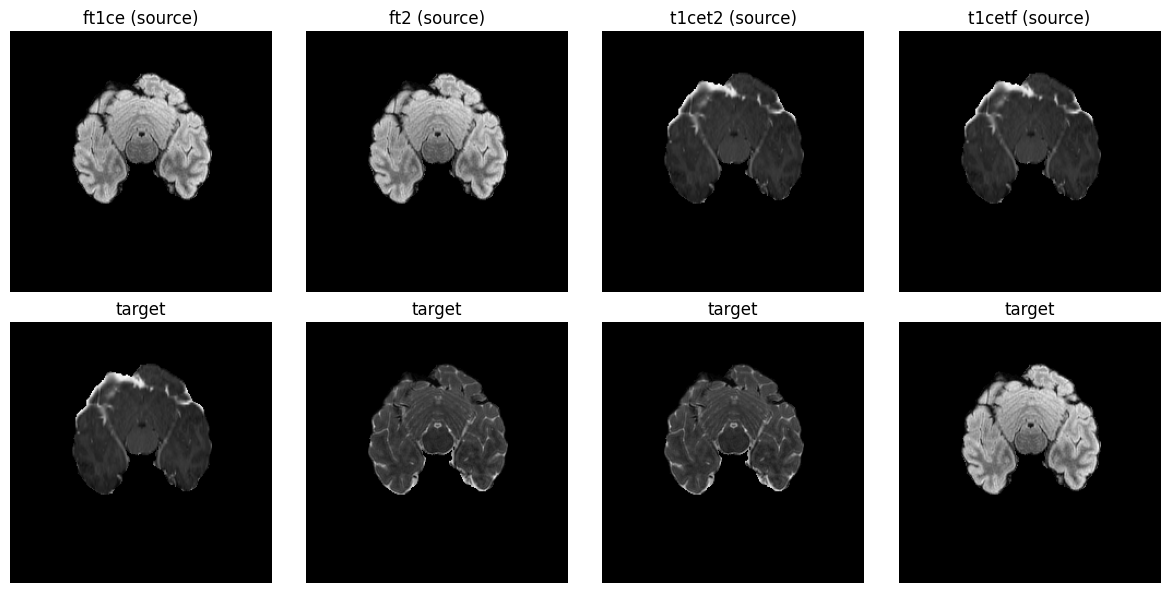

In [4]:
import matplotlib.pyplot as plt, nibabel as nib, os

n = min(4, len(train_files))
fig, ax = plt.subplots(2, n, figsize=(3 * n, 6))
ax = ax.reshape(2, n)
for i, f in enumerate(train_files[:n]):
    arr = nib.load(f).get_fdata()
    ax[0, i].imshow(arr[..., 0].T, cmap='gray', origin='lower')
    ax[0, i].set_title(os.path.basename(f).split('_')[3] + ' (source)'); ax[0, i].axis('off')
    ax[1, i].imshow(arr[..., 1].T, cmap='gray', origin='lower')
    ax[1, i].set_title('target'); ax[1, i].axis('off')
plt.tight_layout(); plt.show()

## 5. Smoke test
A quick tiny run to confirm the whole pipeline works before the long training.

In [5]:
import os, shutil

os.environ['DIFFUSION_TRAINING_TEST'] = '1'
get_ipython().system('python scripts/train_translation.py model.num_channels=32 model.num_res_blocks=1 training.batch_size=2 training.save_interval=2 training.log_interval=100')
os.environ.pop('DIFFUSION_TRAINING_TEST', None)

ckpts = [f for f in os.listdir('results') if f.startswith('savedmodel')]
assert ckpts, 'no checkpoint produced - pipeline broken!'
print('Smoke test OK - produced:', sorted(ckpts))
shutil.rmtree('results')  # discard the throwaway checkpoints

Logging to ./results
creating model and diffusion...
creating data loader...
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
training...
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if neces

## 6. Train
Full training (needs a GPU). Hyper-parameters via Hydra overrides; `lr_anneal_steps` bounds the run.

In [ ]:
get_ipython().system('python scripts/train_translation.py training.batch_size=4 training.lr=1e-4 training.save_interval=5000 training.lr_anneal_steps=100000')

Logging to ./results
creating model and diffusion...
creating data loader...
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
training...
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if neces

## 7. Sample translated images

In [7]:
import glob
ckpts = sorted(glob.glob('results/savedmodel*.pt'))
CKPT = ckpts[-1] if ckpts else './results/savedmodel.pt'
print('Using checkpoint:', CKPT)
get_ipython().system(f'python scripts/sampling_translation.py sampling.model_path={CKPT} sampling.num_ensemble=5 sampling.num_samples=4')
print('Outputs (.pt) saved under ./results')

Using checkpoint: results/savedmodel000000.pt
Logging to ./results
creating model and diffusion...
loading model weights from results/savedmodel000000.pt...
Setting up a new session...
Visdom server not reachable — visualizations disabled.
sampling...
[rank0]: Traceback (most recent call last):
[rank0]:   File "/content/mmit-ddpm/scripts/sampling_translation.py", line 118, in <module>
[rank0]:     main()
[rank0]:   File "/usr/local/lib/python3.12/dist-packages/hydra/main.py", line 94, in decorated_main
[rank0]:     _run_hydra(
[rank0]:   File "/usr/local/lib/python3.12/dist-packages/hydra/_internal/utils.py", line 394, in _run_hydra
[rank0]:     _run_app(
[rank0]:   File "/usr/local/lib/python3.12/dist-packages/hydra/_internal/utils.py", line 457, in _run_app
[rank0]:     run_and_report(
[rank0]:   File "/usr/local/lib/python3.12/dist-packages/hydra/_internal/utils.py", line 220, in run_and_report
[rank0]:     return func()
[rank0]:            ^^^^^^
[rank0]:   File "/usr/local/lib/pyt

## 8. Evaluate (PSNR / SSIM / MAE)
Evaluation needs ground truth, so it runs on paired slices (`data/training`). `timestep_respacing` trades speed for accuracy.

In [8]:
import glob, pandas as pd
ckpts = sorted(glob.glob('results/savedmodel*.pt'))
CKPT = ckpts[-1] if ckpts else './results/savedmodel.pt'
get_ipython().system(f'python scripts/evaluate_translation.py eval.model_path={CKPT} eval.data_dir=./data/training eval.num_eval=20 diffusion.timestep_respacing=100')
metrics = pd.read_csv('results/metrics.csv')
print(metrics.describe())
metrics.head()

Logging to ./results
evaluating 6 slice(s) from ./data/training...
[rank0]: Traceback (most recent call last):
[rank0]:   File "/content/mmit-ddpm/scripts/evaluate_translation.py", line 110, in <module>
[rank0]:     main()
[rank0]:   File "/usr/local/lib/python3.12/dist-packages/hydra/main.py", line 94, in decorated_main
[rank0]:     _run_hydra(
[rank0]:   File "/usr/local/lib/python3.12/dist-packages/hydra/_internal/utils.py", line 394, in _run_hydra
[rank0]:     _run_app(
[rank0]:   File "/usr/local/lib/python3.12/dist-packages/hydra/_internal/utils.py", line 457, in _run_app
[rank0]:     run_and_report(
[rank0]:   File "/usr/local/lib/python3.12/dist-packages/hydra/_internal/utils.py", line 220, in run_and_report
[rank0]:     return func()
[rank0]:            ^^^^^^
[rank0]:   File "/usr/local/lib/python3.12/dist-packages/hydra/_internal/utils.py", line 458, in <lambda>
[rank0]:     lambda: hydra.run(
[rank0]:             ^^^^^^^^^^
[rank0]:   File "/usr/local/lib/python3.12/dist-pa

FileNotFoundError: [Errno 2] No such file or directory: 'results/metrics.csv'

## 9. Save model weights

In [ ]:
import glob, shutil, os
ckpts = sorted(glob.glob('results/*.pt'))
try:
    from google.colab import drive
    drive.mount('/content/drive')
    dst = '/content/drive/MyDrive/mmit-ddpm-weights'
    os.makedirs(dst, exist_ok=True)
    for c in ckpts:
        shutil.copy(c, dst)
    print(f'Copied {len(ckpts)} checkpoint(s) to {dst}')
except Exception as e:
    print('Google Drive unavailable, zipping instead:', e)
    shutil.make_archive('mmit-ddpm-weights', 'zip', 'results')
    print('Saved mmit-ddpm-weights.zip in', os.getcwd())
    try:
        from google.colab import files
        files.download('mmit-ddpm-weights.zip')
    except Exception:
        pass